**Homework 1**

Two tasks based on Practice 1 (aliasing, Fourier, filtering). Each one needs more than one filter/trick combined, not just one.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq

np.random.seed(42)

**1. Disguised radio station**

A secret tone between 60-90 Hz gets sampled at fs=100 Hz -- too slow, so it aliases. There's also a 50 Hz hum and some noise mixed in.

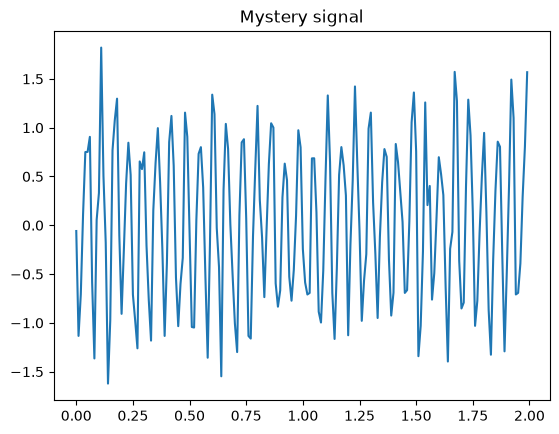

In [51]:
# mystery signal -- don't peek at secret_freq
fs = 100
t = np.arange(0, 2, 1/fs)
secret_freq = np.random.choice([63, 71, 77, 84])

mystery_signal = (np.sin(2*np.pi*secret_freq*t)
                   + 0.7*np.sin(2*np.pi*50*t)
                   + 0.3*np.random.randn(len(t)))

plt.plot(t, mystery_signal)
plt.title('Mystery signal')
plt.show()

In [52]:
# TODO: FFT it, plot the spectrum, find the peaks, and use f_alias = |f_in - k*fs| to guess secret_freq

signal_length = 2

N = fs * signal_length
freqs = np.fft.fftfreq(N, d=1/fs)

mystery_signal_fft = fft(mystery_signal)

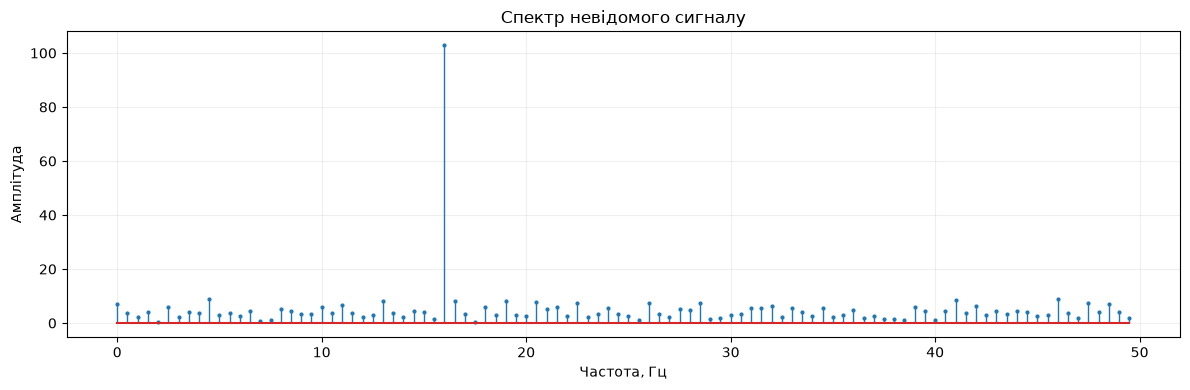

In [53]:
plt.figure(figsize=(12, 4))
markerline, stemlines, baseline = plt.stem(freqs[:N//2], np.abs(mystery_signal_fft[:N//2]))
plt.setp(stemlines, linewidth=1)
plt.setp(markerline, markersize=2)
plt.xlabel('Частота, Гц')
plt.ylabel('Амплітуда')
plt.title('Спектр невідомого сигналу')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [54]:
from scipy.signal import find_peaks

'''
    Щоб знайти пік, використаю find_peaks + prominence (вибирається індивідуально під кожен кейс)
        параметр prominence дозволяє знайти пік: вибираємо вищу долину (ліва чи права) і
            порівнюємо із заданим значенням
        підбираємо значення вручну (5 ... 10) і множимо на медіану, адже медіана стійка до викидів,
            на відміну від середнього по сигналу - дозволяє виділити реально шукані піки
'''

mag = np.abs(mystery_signal_fft[:N//2])
peaks, props = find_peaks(mag, prominence=5*np.median(mag))
peak_freqs = freqs[peaks]

for f, m in zip(peak_freqs, mag[peaks]):
    print(f"{f:.2f} Гц - амплітуда {m:.2f}")

16.00 Гц - амплітуда 102.88


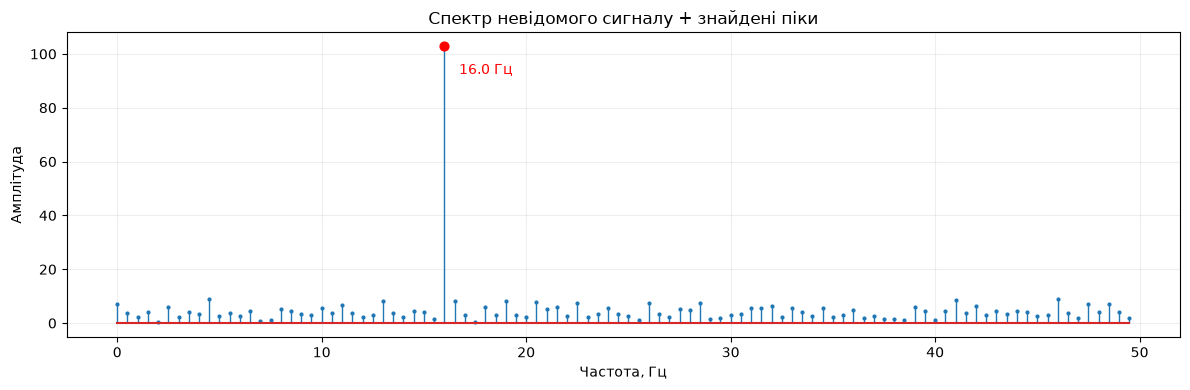

In [55]:
best = peaks[np.argmax(mag[peaks])]

plt.figure(figsize=(12, 4))
markerline, stemlines, baseline = plt.stem(freqs[:N//2], np.abs(mystery_signal_fft[:N//2]))
plt.scatter(peak_freqs, mag[peaks], color='red', zorder=3, s=40, label='Знайдені піки')
plt.setp(stemlines, linewidth=1)
plt.setp(markerline, markersize=2)
plt.xlabel('Частота, Гц')
plt.ylabel('Амплітуда')
plt.title('Спектр невідомого сигналу + знайдені піки')
plt.grid(alpha=0.2)
plt.annotate(f'{freqs[best]:.1f} Гц', (freqs[best], mag[best]),
             textcoords="offset points", xytext=(30, -20), ha='center', color='red')
plt.tight_layout()
plt.show()

In [56]:
peak_freqs

array([16.])

In [57]:
f_alias = freqs[best]

f_true = fs - f_alias

print(f"Шукана секретна частота {int(f_true)} Гц")

Шукана секретна частота 84 Гц


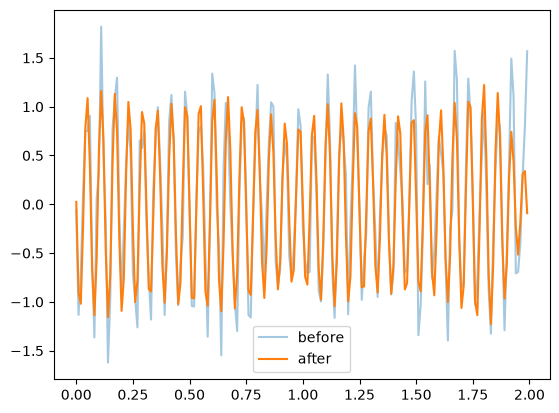

In [58]:
# TODO: chain two filters -- iirnotch to kill the 50 Hz hum, then butter+filtfilt to kill leftover noise
b_notch, a_notch = signal.iirnotch(50, Q=30, fs=fs)
stage1 = signal.lfilter(b_notch, a_notch, mystery_signal)
b_bp, a_bp = signal.butter(4, [f_alias - 3, f_alias + 3], btype='bandpass', fs=fs)
stage2 = signal.filtfilt(b_bp, a_bp, stage1)

plt.plot(t, mystery_signal, alpha=0.4, label='before')
plt.plot(t, stage2, label='after')
plt.legend()
plt.show()

**2. Build your own combo filter**

`x_noisy` has noise, a 60 Hz spike, and drift (baseline slowly climbing). Try MA/PT1/windowed-sinc/butter one at a time, then build a combo of two or more stages that cleans up all three problems.

Hint: think about which of your filters are low-pass vs high-pass, and which kind actually targets the drift.

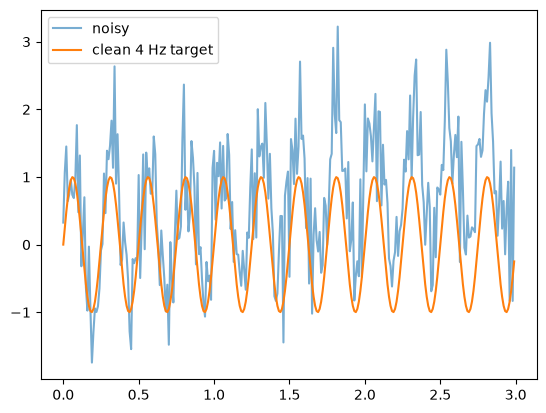

In [59]:
fs3 = 100
t3 = np.arange(0, 3, 1/fs3)
x_clean = np.sin(2*np.pi*4*t3)
x_noisy = x_clean + 0.5*np.random.randn(len(t3)) + 0.3*np.sin(2*np.pi*60*t3) + 0.02*t3*20

plt.plot(t3, x_noisy, alpha=0.6, label='noisy')
plt.plot(t3, x_clean, label='clean 4 Hz target')
plt.legend()
plt.show()

In [ ]:
# TODO: apply MA, PT1, windowed-sinc, and butter separately, plot all four against x_noisy


In [ ]:
# TODO: chain at least two filters into your own combo (one to kill the drift, one for the rest)
# plot combo vs x_noisy vs x_clean

*which stage removed the drift, which killed the 60 Hz spike, which smoothed the noise?*